# Veri Analizi Okulu – Yapay Zeka
## Derin Öğrenme

**Hazırlayan:** Emre Fişne  
**Kurum:** Boğaziçi Üniversitesi / Veri Bilimi ve Yapay Zeka Enstitüsü
**Tarih:** 10 Nisan 2026

---

Bu notebook, derin öğrenmenin temel fikirlerini pratik örnekler üzerinden tanıtmak amacıyla hazırlanmıştır.
İçerikte gradyan kavramlarından başlayarak, yapay sinir ağları, backpropagation ve modern derin öğrenme yapı taşlarına uzanan örnekler yer almaktadır.

## İçindekiler
1. Türev ve sezgisel anlamı
2. Sayısal türev yaklaşımı
3. Gradyan ve optimizasyon fikri
4. Basit nöron modeli
5. Çok katmanlı algılayıcı (MLP)
6. Eğitim mantığı ve loss
7. PyTorch ile temel eğitim döngüsü
8. Transformer mantığına giriş
9. Basit GPT modeli eğitimi

## Öğrenme Hedefleri
Bu notebook sonunda:
- türev ve gradyanın neden önemli olduğunu,
- bir sinir ağının temel çalışma mantığını,
- geri yayılımın neyi hesapladığını,
- PyTorch ile basit bir modelin nasıl eğitildiğini,
- transformer yapısının temel sezgisini

anlıyor olmanız hedeflenmektedir.

# *Kısım 1*

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

##  Türev: Bir Fonksiyonun Türevi <a id="001"></a>
------
Bir fonksiyon tanımlayıp görselleştirelim.

$$
f(x) = \left(5x^2 + 3\right)^{\frac{1}{2}}
$$

In [ ]:
def f(x):
    return (5*x**2 + 3)**0.5

In [ ]:
f(3.0)

6.928203230275509

In [ ]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [ ]:
ys = f(xs)
ys

array([11.3137085 , 10.76162163, 10.21028893,  9.65983954,  9.11043358,
        8.56227189,  8.01560977,  7.4707764 ,  6.92820323,  6.38846617,
        5.85234996,  5.32094916,  4.79583152,  4.27931069,  3.77491722,
        3.28823661,  2.82842712,  2.41091269,  2.06155281,  1.82002747,
        1.73205081,  1.82002747,  2.06155281,  2.41091269,  2.82842712,
        3.28823661,  3.77491722,  4.27931069,  4.79583152,  5.32094916,
        5.85234996,  6.38846617,  6.92820323,  7.4707764 ,  8.01560977,
        8.56227189,  9.11043358,  9.65983954, 10.21028893, 10.76162163])

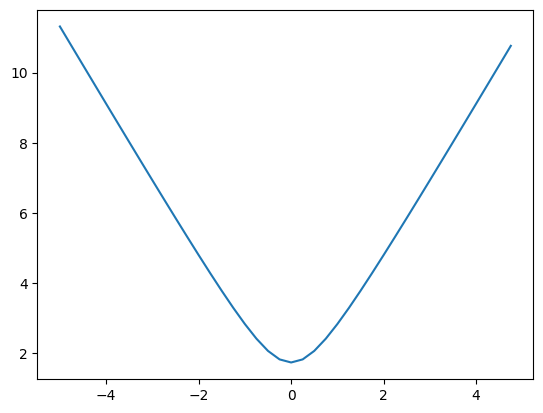

In [ ]:
plt.plot(xs, ys)
plt.show()

Bir Fonksiyonun Türevi Nedir? Eğer herhangi bir noktada X eksenindeki çok küçük bir değişikliğe fonksiyonun tepkisi nedir sorusunun cevabıdır.

$$
\frac{d f(x)}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

In [ ]:
h = 0.001
x = -2.0
(f(x + h) - f(x))/h

-2.085076117164242

In [ ]:
h = 0.000001
x = -3.0
(f(x + h) - f(x))/h

-2.1650634867143026

In [ ]:
h = 0.0000001
x = -3.0
türev = (f(x + h) - f(x))/h
türev

-2.165063506254228

# Fonksiyonun türevi için genel tanımı nasıl bulabiliriz: Zincir Kuralı

$$
\frac{dy}{dx} = \frac{dy}{du} \times \frac{du}{dx}
$$

Önce u = g(x) tanımlayalım

$$
g(x) = 5x^2 + 3
$$

In [ ]:
def g(x):
    return 5*x**2 + 3

In [ ]:
def f(x):
    return g(x)**(1/2)

In [ ]:
def g_türev_x(x):
    return 10 * x

$$
f'(g(x)) = \frac{1}{2}\,(g(x))^{-\frac{1}{2}}
$$

In [ ]:
def f_türev_gx(g, x):
    return (1/2) * (g(x)**(-1/2))

In [ ]:
def f_türev_x_zincir(x):
    return f_türev_gx(g, x) * g_türev_x(x)

In [ ]:
x = -3.0
print(f"x=-3'te türevi: {f_türev_x_zincir(x)}")

x=-3'te türevi: -2.1650635094610964


In [ ]:
f_türev_x_zincir(x) - türev

-3.2068685484887283e-09

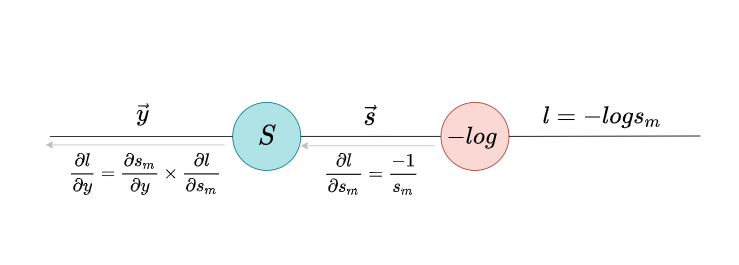

*https://medium.com/data-science/backpropagation-in-rnn-explained-bdf853b4e1c2*

In [ ]:
class Value:
    """ Bir skaler değeri ve gradyantını tutar """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0

        self._backward = lambda: None
        self._prev = set(_children)
        # bu değeri üreten operasyon (toplama? çarpma? sinüs?)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t, (self,), 'exp')

        def _backward():
            self.grad += t * out.grad
        out._backward = _backward

        return out

    def backward(self):
      # düğümlerin graph yapısının oluşturulması
      # DFS (depth-first search)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # her değişkenin gradyanını hesaplamak için
        # graph'ta geriye doğru gidiliyor
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __neg__(self): # -self
        return self * -1

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1


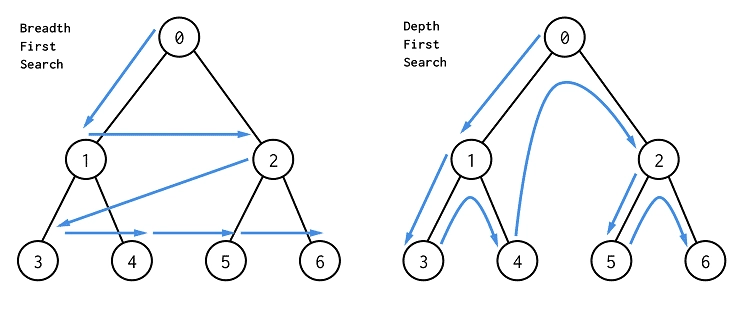

*https://dev.to/danimal92/difference-between-depth-first-search-and-breadth-first-search-6om*

In [ ]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

d = a*b; d.label ='d'
L = d+c; L.label = 'L'
L
L._prev
L._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
    """
    graph oluşturucu
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # n1 düğümünü n2 düğümünün işlemiyle birleştirme
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

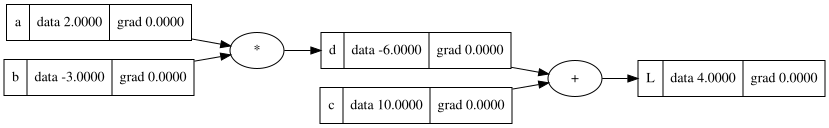

In [ ]:
draw_dot(L)

In [ ]:
L.backward()

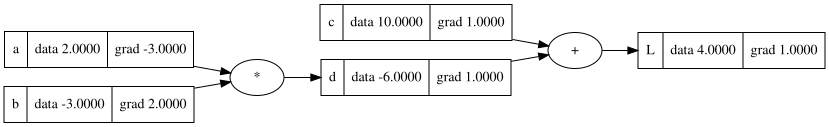

In [ ]:
draw_dot(L)

In [ ]:
print(f"L grad: {L.grad:.4f}") # dL/dL = 1.0
print(f"d grad: {d.grad:.4f}") # dL/dd = 1.0
print(f"c grad: {c.grad:.4f}") # dL/dc = 1.0
print(f"a grad: {a.grad:.4f}") # dL/da = (dL/dd) * (dd/da) = 1.0 * b.data
print(f"b grad: {b.grad:.4f}") # dL/db = (dL/dd) * (dd/db) = 1.0 * a.data

L grad: 1.0000
d grad: 1.0000
c grad: 1.0000
a grad: -3.0000
b grad: 2.0000


# Optimizasyon

In [ ]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
d.data += 0.01 * d.grad

d = a*b
L = d+c

print(L.data)

4.1394


**Nöron Yapısı**

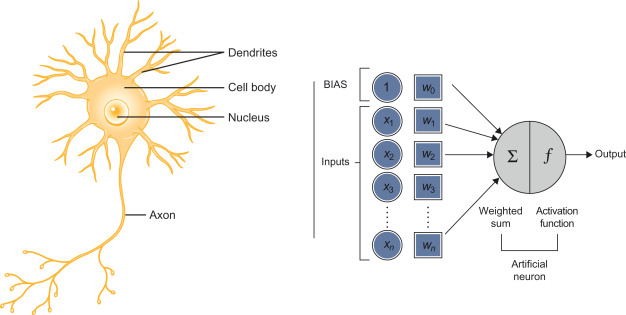

Chang, A. C. (2020). *Intelligence-based medicine: artificial intelligence and human cognition in clinical medicine and healthcare*. Academic Press.

In [ ]:
# girişler
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# ağırlıklar
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# bias
b = Value(6.8813735870195432,label='b')
# çıkış = x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh()
o.label = 'o'

In [ ]:
o.grad = 1.0           #do/do = 1

o._backward()          #do/dn
n._backward()          #do/db = do/d(x1w1+x2w2)
b._backward()
x1w1x2w2._backward()   #do/d(x1w1) = do/d(x2w2)
x2w2._backward()       #do/d(x2), do/d(w2)
x1w1._backward()       #do/d(x1), do/d(w1)

In [ ]:
o.grad

1.0

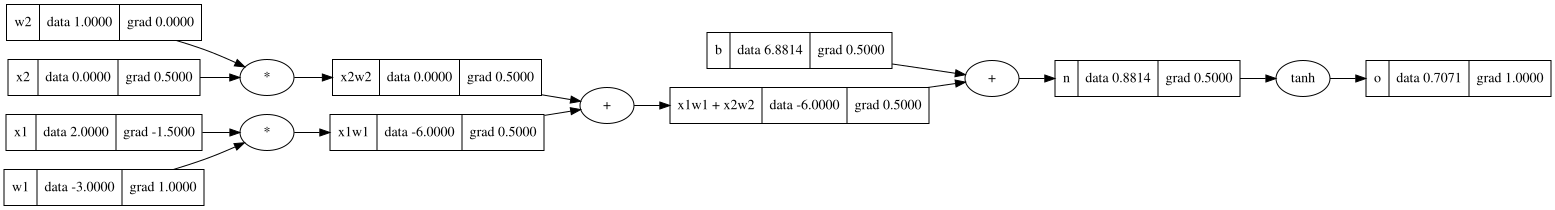

In [ ]:
draw_dot(o)

# *Kısım 2*

**PyTorch**

In [ ]:
import torch

torch.Tensor([[1, 2, 3], [4, 5, 6]]),\
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape

(tensor([[1., 2., 3.],
         [4., 5., 6.]]),
 torch.Size([2, 3]))

In [ ]:
x1 = torch.tensor([2.0])    ;x1.requires_grad=True
w1 = torch.tensor([-3.0])   ;w1.requires_grad=True
x2 = torch.tensor([0.0])     ;x2.requires_grad=True
w2 = torch.tensor([1.0])     ;w2.requires_grad=True
b  = torch.tensor([6.8813735870195432])     ;b.requires_grad=True
n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071067094802856
-----
x2 0.5000001192092896
w2 0.0
x1 -1.5000003576278687
w1 1.000000238418579


**Sinir Ağı Katmanları**

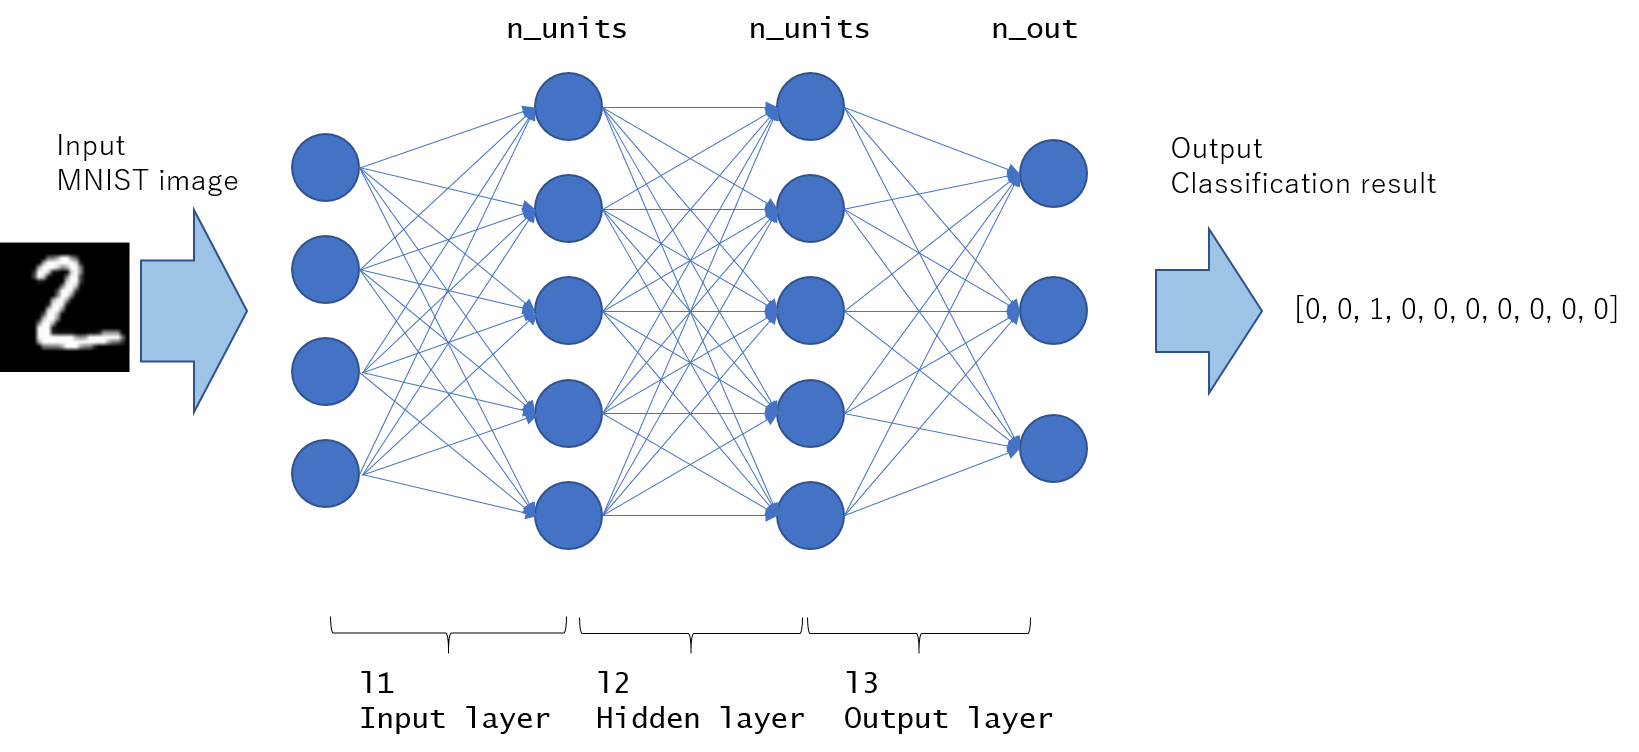

*https://corochann.com/mnist-training-with-multi-layer-perceptron-536/*

In [ ]:
import random

class Neuron:
    """ Yapay nöron sınıfı"""

    def __init__(self, nin):
        """ rastgele ağırlıklar ile başlar
        """
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x): # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)),  self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

In [ ]:
class Layer:
    """ Sinir ağı katmanı sınıfı """

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [param for neuron in self.neurons for param in neuron.parameters()]

In [ ]:
class MLP:
    """ Çok katmanlı yapay sinir ağı sınıfı"""

    def __init__(self, nin, nouts):
        """
        nin: int
            giriş boyutu
        nouts: list
            katman sayısı
        """
        sz = [nin] + nouts
        self.layers= [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [ ]:
x = [2.0, 3.0]
a = Neuron(2)
a(x)

Value(data=0.9750995637050248, grad=0.0)

In [ ]:
x = [1.0, 1.0]
b =  Layer(2, 3)
b(x)

[Value(data=0.8299405558869526, grad=0.0),
 Value(data=-0.9896314177742245, grad=0.0),
 Value(data=-0.8328198551337482, grad=0.0)]

In [ ]:
# giriş
x = [2.0, 3.0, -1.0]

# yapay sinir ağı instance'ı
mlp = MLP(3, [4, 4, 1])

# forward pass
mlp(x)

Value(data=0.12727807904037555, grad=0.0)

In [ ]:
def Loss(prediction, target):
  loss = 0
  for target_, prediction_ in zip(target, prediction):
    loss += (prediction_ - target_)**2
  return loss

# Yapay Sinir Ağıyla Multiplexer Fonksiyonunu Öğrenmek

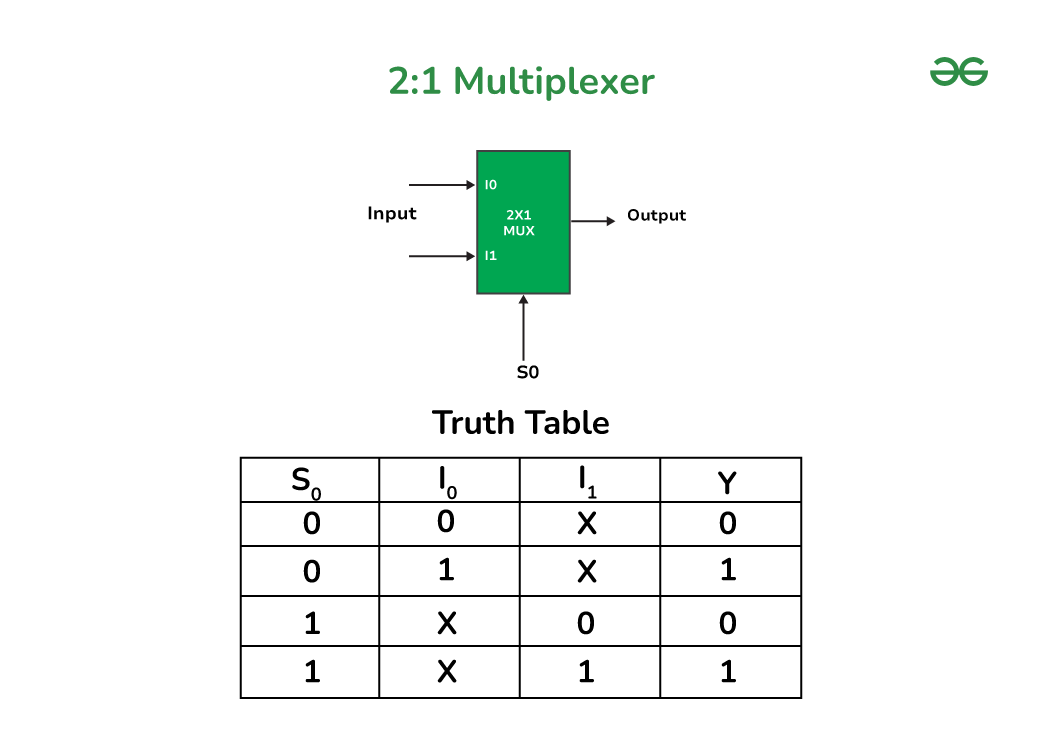

*https://www.geeksforgeeks.org/digital-logic/multiplexers-in-digital-logic/*

In [ ]:
# format: [giriş_A, giriş_B, kontrol]
x_data = [
    [ 1.0,  1.0, -1.0], # S=0, Output  A (1.0)
    [ 1.0, -1.0, -1.0], # S=0, Output  A (1.0)
    [-1.0,  1.0, -1.0], # S=0, Output  A (-1.0)
    [-1.0, -1.0, -1.0], # S=0, Output  A (-1.0)
    [ 1.0,  1.0,  1.0], # S=1, Output  B (1.0)
    [ 1.0, -1.0,  1.0], # S=1, Output  B (-1.0)
    [-1.0,  1.0,  1.0], # S=1, Output  B (1.0)
    [-1.0, -1.0,  1.0], # S=1, Output  B (-1.0)
]

# hedef ddeğerler (MUX çıkışları)
y_data = [1.0, 1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0]

In [ ]:
def train_MLP(n_iter=20, learning_rate=0.01):
    losses, steps = [], []
    step = 0
    for k in range(n_iter):
        step += 1
        steps.append(step)
        # forward pass
        ypred = [mlp(x) for x in x_data]
        total_loss = Loss(ypred, y_data)
        # total_loss = loss
        losses.append(total_loss.data)

        # gradyanlar resetlenir
        for p in mlp.parameters():
            p.grad = 0.0
        total_loss.backward()

        # parametre güncelleme
        for p in mlp.parameters():
            p.data += -1 * learning_rate * p.grad

        print(k, total_loss.data)
    return [steps, losses]

In [ ]:
_train_loss = train_MLP(40, 0.05)

0 13.983836913859665
1 9.317276354910376
2 6.870492600948767
3 5.746156717834862
4 5.150573548287906
5 4.67254809957898
6 4.281796680127548
7 3.967787974708581
8 3.700540037706354
9 3.453294388223429
10 3.2030089015416707
11 2.9341415218180846
12 2.6365843784368996
13 2.30717058099759
14 1.9544915657633486
15 1.6040939032000805
16 1.2912079407850983
17 1.0392986523370187
18 0.8492400372234327
19 0.7087327532334601
20 0.6039683598453891
21 0.524206034018787
22 0.46201827509752746
23 0.41242310690051825
24 0.3720640724467971
25 0.3386389033073587
26 0.3105327906040236
27 0.2865870306268454
28 0.26595203031886344
29 0.24799232729633297
30 0.23222395966439724
31 0.21827229095367878
32 0.20584302347454206
33 0.19470188773728886
34 0.18466015291920013
35 0.17556411675903466
36 0.16728736422416873
37 0.15972498450477887
38 0.1527891944095331
39 0.146405986188936


In [ ]:
mlp([ 1.0,  1.0, -1.0])

Value(data=0.9968183182046283, grad=0.0)

# Derin Öğrenme ile Sentiment Analizi (Burada kaldık)

# Tokenization

Uygulamanın ayrıntılarına girmeden önce, tokenizasyon sürecini belli bir derinlikte anlamanın neden gerekli olduğunu kısaca gerekçelendirelim. Tokenizasyon, LLM’lerde gördüğümüz birçok davranışın merkezinde yer alır. Sinir ağı mimarisiyle ilgiliymiş gibi görünen pek çok sorun, büyük ihtimalle tokenizasyona dayanır.

LLM’ler neden kelimeleri doğru heceleyemiyor? Tokenizasyon.

LLM’ler neden bir karakter dizisini ters çevirmek gibi aşırı basit string işleme görevlerinde zorlanıyor? Tokenizasyon.

LLM’ler neden İngilizce dışındaki dillerde, örneğin Japoncada, daha kötü performans gösteriyor? Tokenizasyon.

LLM’ler neden basit aritmetikte başarısız oluyor? Tokenizasyon.

**BPE(byte pair Encoder) Tokenizer**

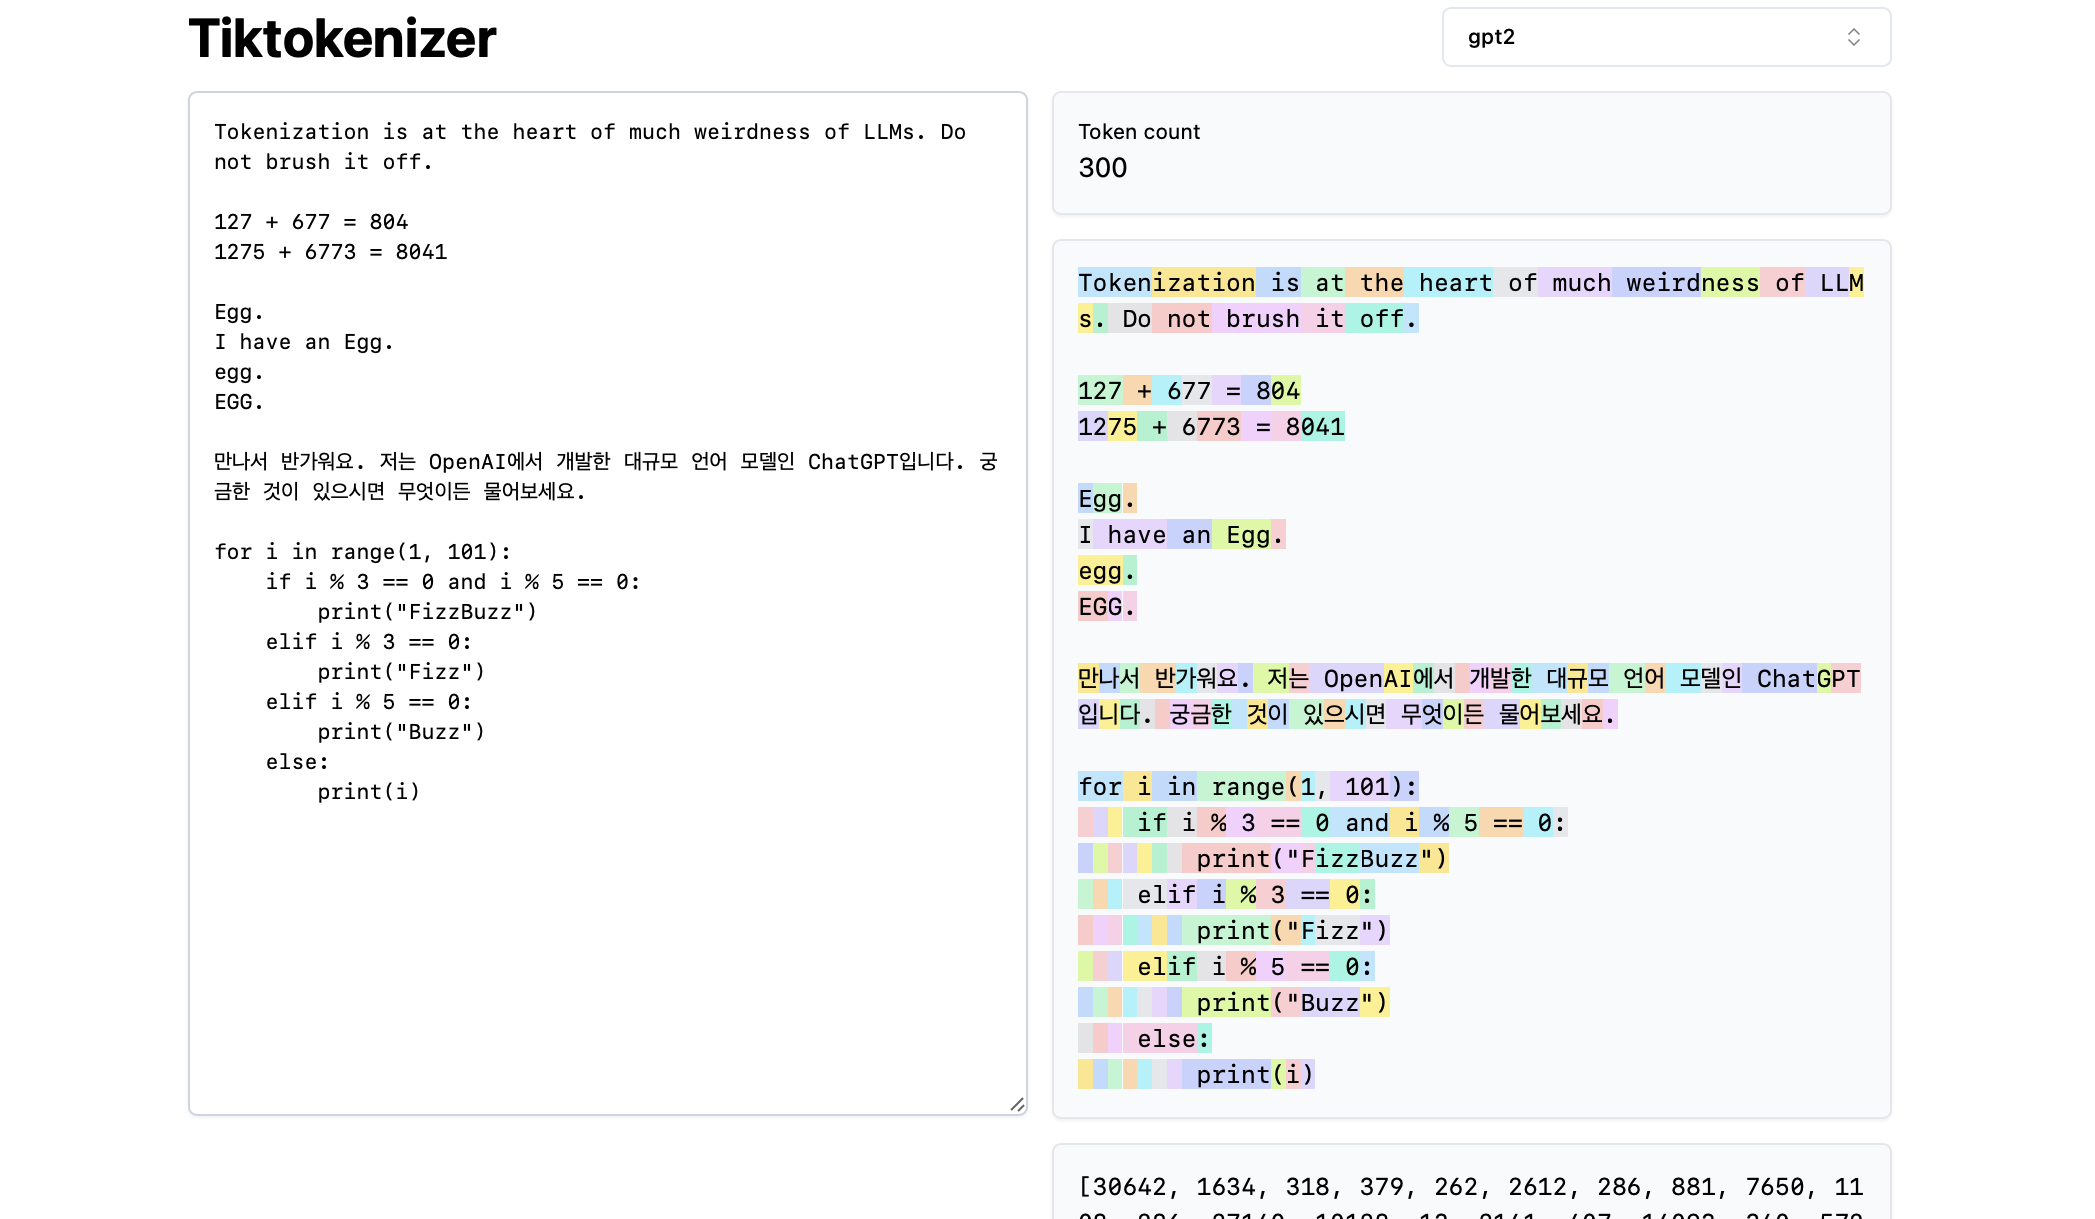

*https://www.fast.ai/posts/2025-10-16-karpathy-tokenizers*

<div style="display: flex; align-items: center; justify-content: center; font-family: sans-serif;">
  <div style="border: 2px solid #4a90e2; padding: 10px; border-radius: 5px;">Raw Text</div>
  <div style="margin: 0 10px;">➔</div>
  <div style="border: 2px solid #50b3a2; padding: 10px; border-radius: 5px; background-color: #f0fdfa;">Tokenizer</div>
  <div style="margin: 0 10px;">➔</div>
  <div style="border: 2px solid #e67e22; padding: 10px; border-radius: 5px;">Token Sequence</div>
  <div style="margin: 0 10px;">➔</div>
  <div style="border: 2px solid #9b59b6; padding: 10px; border-radius: 5px; background-color: #f5f3ff;">Language Model</div>
</div>

In [ ]:
# string'ten integer'a
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
print(stoi)
print(itos)

# encoder-decoder dönüşümleri
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(encode("merhaba nasilsin"))
print(decode(encode("tesekkurler")))

{'\n': 0, ' ': 1, '!': 2, '"': 3, '#': 4, '$': 5, '%': 6, '&': 7, "'": 8, '(': 9, ')': 10, '*': 11, ',': 12, '-': 13, '.': 14, '/': 15, '0': 16, '1': 17, '2': 18, '3': 19, '4': 20, '5': 21, '6': 22, '7': 23, '8': 24, '9': 25, ':': 26, ';': 27, '=': 28, '?': 29, 'A': 30, 'B': 31, 'C': 32, 'D': 33, 'E': 34, 'F': 35, 'G': 36, 'H': 37, 'I': 38, 'J': 39, 'K': 40, 'L': 41, 'M': 42, 'N': 43, 'O': 44, 'P': 45, 'Q': 46, 'R': 47, 'S': 48, 'T': 49, 'U': 50, 'V': 51, 'W': 52, 'X': 53, 'Y': 54, 'Z': 55, '[': 56, ']': 57, '_': 58, 'a': 59, 'b': 60, 'c': 61, 'd': 62, 'e': 63, 'f': 64, 'g': 65, 'h': 66, 'i': 67, 'j': 68, 'k': 69, 'l': 70, 'm': 71, 'n': 72, 'o': 73, 'p': 74, 'q': 75, 'r': 76, 's': 77, 't': 78, 'u': 79, 'v': 80, 'w': 81, 'x': 82, 'y': 83, 'z': 84, '{': 85, 'à': 86, 'â': 87, 'ä': 88, 'æ': 89, 'ç': 90, 'è': 91, 'é': 92, 'ê': 93, 'ë': 94, 'ö': 95, 'ü': 96, 'œ': 97, '—': 98, '‘': 99, '’': 100, '“': 101, '”': 102, '•': 103, '™': 104, '\ufeff': 105}
{0: '\n', 1: ' ', 2: '!', 3: '"', 4: '#', 5

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# Sentiment veri seti
data = [
    ("this movie is amazing", 1),
    ("i really loved this film", 1),
    ("what a wonderful story", 1),
    ("the acting was fantastic", 1),
    ("this film was inspiring", 1),
    ("i enjoyed every moment", 1),
    ("this movie is boring", 0),
    ("i hated this film", 0),
    ("what a terrible story", 0),
    ("the acting was awful", 0),
    ("this film was disappointing", 0),
    ("i regret watching it", 0),
]

In [ ]:
# Tokenization
def tokenize(text):
    return text.lower().split()

In [ ]:
# Vocab oluşturma
vocab = {"<PAD>": 0, "<UNK>": 1}
for text, _ in data:
    for token in tokenize(text):
        if token not in vocab:
            vocab[token] = len(vocab)

In [ ]:
# cümleleri encode etme
def encode(text):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokenize(text)]

In [ ]:
encoded_data = [(encode(text), label) for text, label in data]

# padding
max_len = max(len(x) for x, _ in encoded_data)

def pad_sequence(seq, max_len):
    return seq + [vocab["<PAD>"]] * (max_len - len(seq))

X = torch.tensor([pad_sequence(seq, max_len) for seq, _ in encoded_data], dtype=torch.long)
y = torch.tensor([label for _, label in encoded_data], dtype=torch.long)

In [ ]:
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                    # (B, T, D)
        mask = (x != 0).unsqueeze(-1)              # (B, T, 1)
        emb = emb * mask
        summed = emb.sum(dim=1)                    # (B, D)
        lengths = mask.sum(dim=1).clamp(min=1)     # (B, 1)
        mean_pooled = summed / lengths
        logits = self.fc(mean_pooled)              # (B, 2)
        return logits

In [ ]:
def get_param_vector(model):
    return torch.cat([p.detach().flatten().cpu() for p in model.parameters()])

In [ ]:
model = SentimentClassifier(vocab_size=len(vocab))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
!pip install loss-landscapes

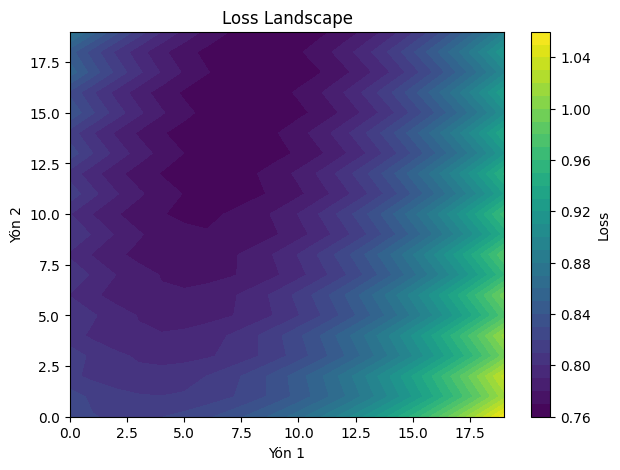

In [ ]:
import loss_landscapes
import loss_landscapes.metrics
import matplotlib.pyplot as plt
import numpy as np

# metric
metric = loss_landscapes.metrics.Loss(criterion, X, y)

# 2D loss yüzeyi örnekle
landscape = loss_landscapes.random_plane(model, metric)

Z = np.array(landscape)

plt.figure(figsize=(7, 5))
cp = plt.contourf(Z, levels=30)
plt.colorbar(cp, label="Loss")
plt.title("Loss Landscape")
plt.xlabel("Yön 1")
plt.ylabel("Yön 2")
plt.show()

In [ ]:
for epoch in range(100):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean().item()
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}")



Epoch 00 | Loss: 0.7155 | Accuracy: 0.42
Epoch 05 | Loss: 0.6421 | Accuracy: 0.58
Epoch 10 | Loss: 0.5748 | Accuracy: 1.00
Epoch 15 | Loss: 0.5066 | Accuracy: 0.92
Epoch 20 | Loss: 0.4334 | Accuracy: 1.00
Epoch 25 | Loss: 0.3559 | Accuracy: 1.00
Epoch 30 | Loss: 0.2805 | Accuracy: 1.00
Epoch 35 | Loss: 0.2127 | Accuracy: 1.00
Epoch 40 | Loss: 0.1558 | Accuracy: 1.00
Epoch 45 | Loss: 0.1119 | Accuracy: 1.00
Epoch 50 | Loss: 0.0800 | Accuracy: 1.00
Epoch 55 | Loss: 0.0578 | Accuracy: 1.00
Epoch 60 | Loss: 0.0427 | Accuracy: 1.00
Epoch 65 | Loss: 0.0325 | Accuracy: 1.00
Epoch 70 | Loss: 0.0255 | Accuracy: 1.00
Epoch 75 | Loss: 0.0206 | Accuracy: 1.00
Epoch 80 | Loss: 0.0171 | Accuracy: 1.00
Epoch 85 | Loss: 0.0145 | Accuracy: 1.00
Epoch 90 | Loss: 0.0125 | Accuracy: 1.00
Epoch 95 | Loss: 0.0110 | Accuracy: 1.00


In [ ]:
# örnekler üstünde test
test_sentences = [
    "this movie was fantastic",
    "i hated this story",
    "the film was wonderful",
    "what an awful movie"
]

model.eval()
with torch.no_grad():
    for sentence in test_sentences:
        seq = encode(sentence)
        seq = pad_sequence(seq, max_len)
        x_test = torch.tensor([seq], dtype=torch.long)
        pred = model(x_test).argmax(dim=1).item()
        label = "positive" if pred == 1 else "negative"
        print(f"{sentence!r} -> {label}")

'this movie was fantastic' -> positive
'i hated this story' -> negative
'the film was wonderful' -> positive
'what an awful movie' -> negative


# *Kısım 3*

# Transformers

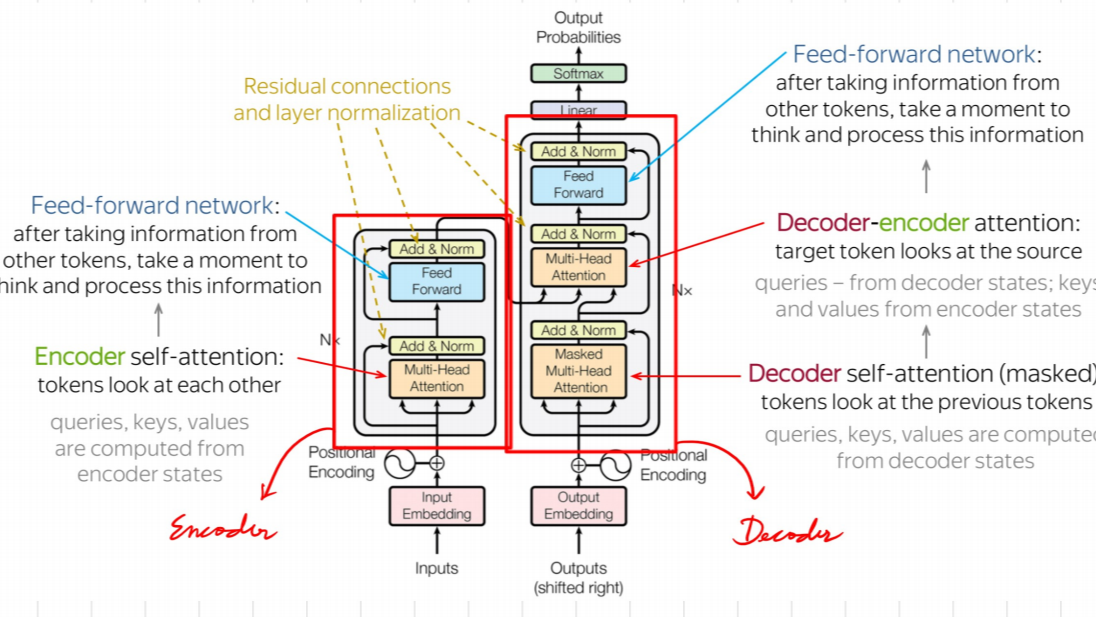

*https://stats.stackexchange.com/questions/512242/why-does-transformer-has-such-a-complex-architecture*

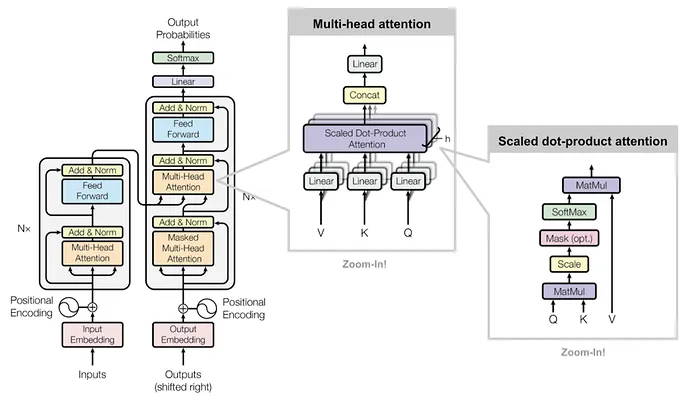

https://blog.csdn.net/weixin_55982578/article/details/159511848

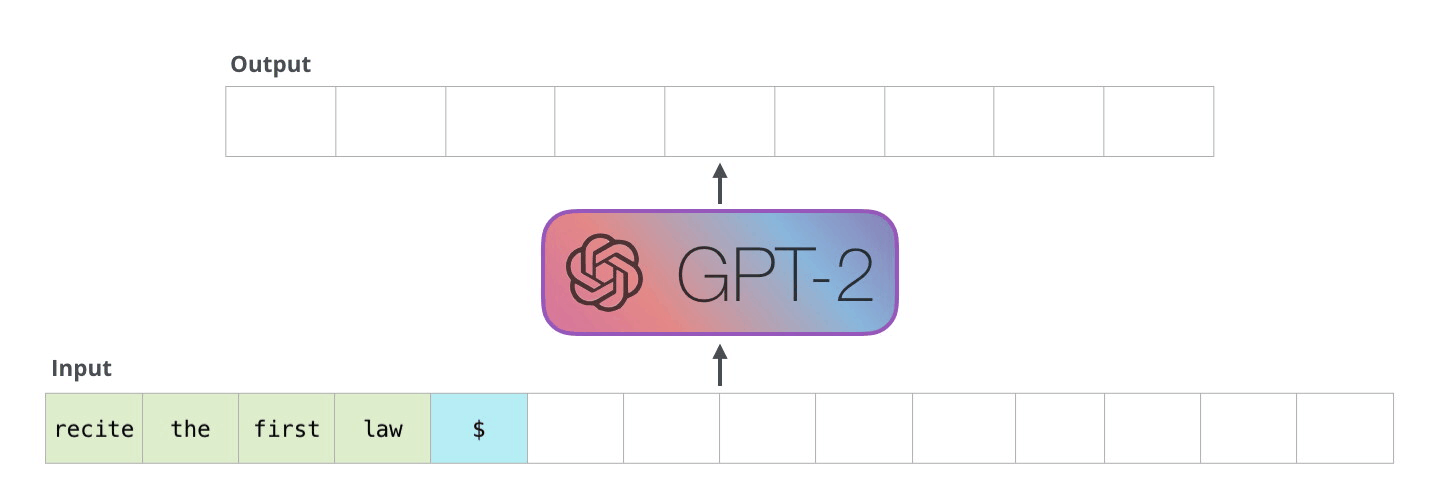

*https://blog.csdn.net/weixin_55982578/article/details/159511848*

Transformer'lar birkaç temel parçadan oluşur:

Self-attention

Multi-head attention

Feed Forward yapay Sinir Ağı

Residual bağlantılar

Layer Normalization

# Attention Mekanizması

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn import functional as F
import matplotlib.pyplot as plt
import math
import numpy as np

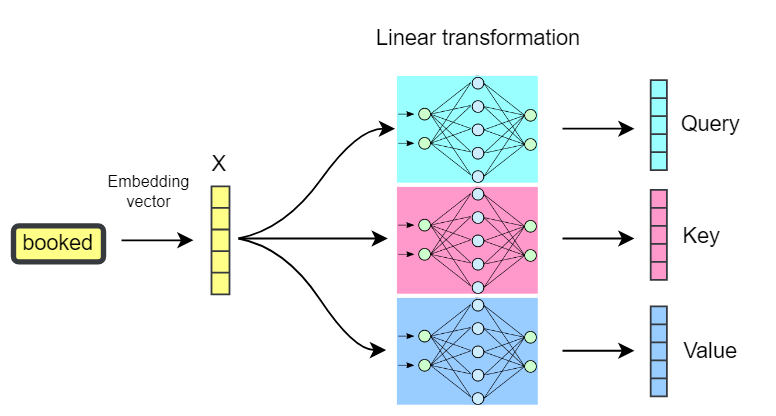

*https://masasikatano.wordpress.com/2024/11/05/unveiling-the-hidden-structure-of-self-attention-via-kernel-principal-component-analysis/*

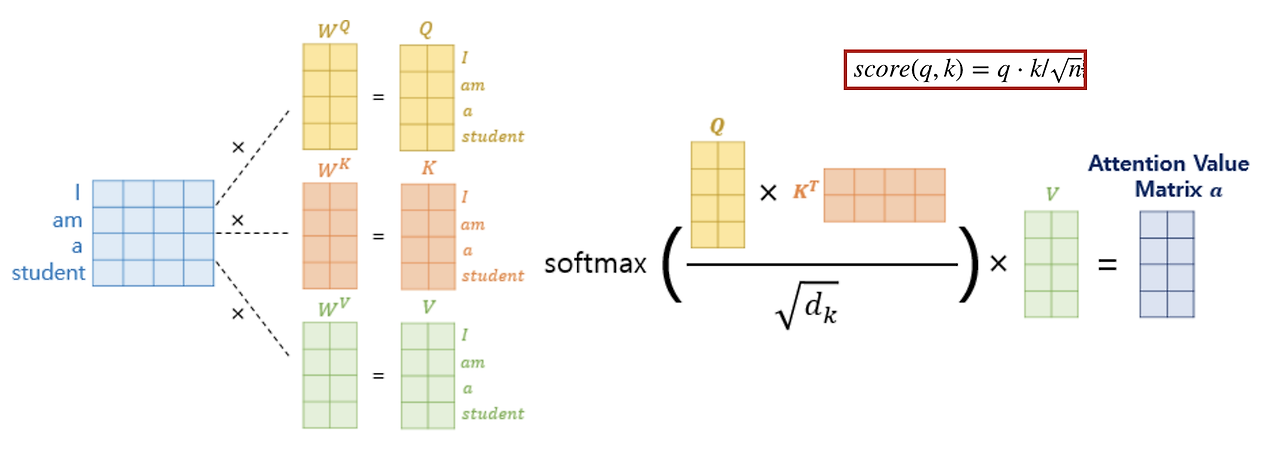

*https://blog.csdn.net/weixin_55982578/article/details/159511848*

In [ ]:
# self-attention
torch.manual_seed(1337)
B,T,C = 1,6,768 # batch, token, channels
# 6 tokens, her biri 768 boyutlu bir embedding
x = torch.randn(B,T,C)

# single-head
head_size = 12
key = nn.Linear(C, int(C/head_size), bias=False) # 768 x 12
query = nn.Linear(C, int(C/head_size), bias=False) # 768 x 12
value = nn.Linear(C, int(C/head_size), bias=False) # 768 x 12
k = key(x)   # (1, 6, 64)
q = query(x) # (1, 6, 64)
wei =  q @ k.transpose(-2, -1) # (B, 6, 64) @ (B, 64, 6) ---> (B, T, T)

# Causal self-attention !
tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([1, 6, 64])

### Lower Triangular Mask

tensor([[1, 0, 0, 0, 0],

        [1, 1, 0, 0, 0],

        [1, 1, 1, 0, 0],

        [1, 1, 1, 1, 0],

        [1, 1, 1, 1, 1]], dtype=torch.int32)

[Transformer Explainer](https://poloclub.github.io/transformer-explainer/)

## Konumsal Kodlama (Positional Encoding, PE)

**Transformer** modelleri, RNN’lerin aksine, dizideki elemanların sırasını doğal olarak bilmez.  
Tüm token’ları aynı anda işlerler. Bu yüzden sıra bilgisini modele bizim ayrıca vermemiz gerekir.

Modelin her elemanın dizide *nerede* olduğunu anlayabilmesi için  
**Konumsal Kodlama (Positional Encoding, PE)** kullanılır.  
Bunlar, token embedding'lerine eklenen sabit ya da öğrenilebilir vektörlerdir.

Bu kodlamalar sayesinde model şunları ayırt edebilir:

> “bu ilk token”, “bu ikinci token”, “bu sona yakın bir token” gibi.

---

### Sinüzoidal Konumsal Kodlama

Orijinal Transformer makalesinde, düzgün periyodik desenler izleyen  
**sinüzoidal positional embeddings** öneriliyor.

Konum $p$ ve embedding boyutu $i$ için:

$$
PE_{(p, 2i)} = \sin\!\left(\frac{p}{10000^{2i / d_{\text{model}}}}\right)
$$

$$
PE_{(p, 2i+1)} = \cos\!\left(\frac{p}{10000^{2i / d_{\text{model}}}}\right)
$$

Bu yapı, her konum için kendine özgü dalga biçimleri üretir.  
Böylece model yalnızca **mutlak konumu** değil, aynı zamanda **göreli konumu** da çıkarabilir.

---

1. Yukarıdaki formüle göre sinüzoidal PE gerçekleştir.  
2. Bunları belirli bir maksimum dizi uzunluğu (max seq len) için (örneğin 5000) önceden hesapla.  
3. Attention katmanlarına vermeden önce giriş embedding'lerine ekle.  
4. Periyodik yapıyı görmek için kodlama desenini görselleştir.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        # PE matrisini hesapla
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return x



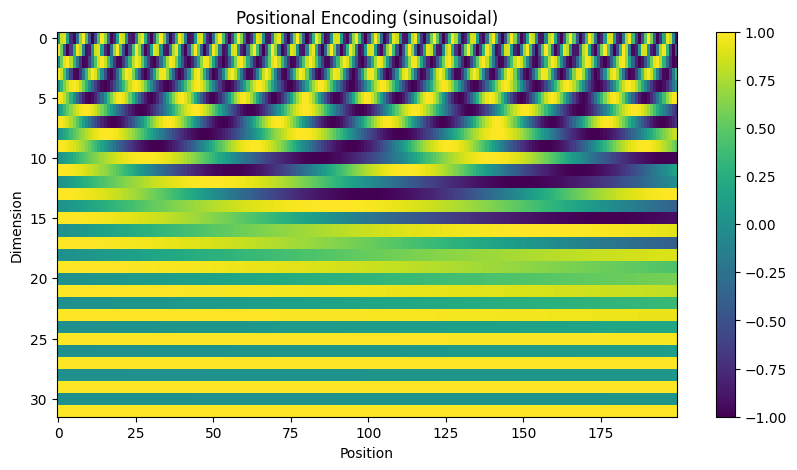

In [ ]:
#  görselleştir
pe = PositionalEncoding(d_model=32, max_len=200).pe.squeeze(0)
plt.figure(figsize=(10, 5))
plt.imshow(pe.T, cmap="viridis", aspect="auto")
plt.title("Positional Encoding (sinusoidal)")
plt.xlabel("Position")
plt.ylabel("Dimension")
plt.colorbar()
plt.show()

İlk attention yapısını oluşturalım.

In [ ]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)                                               # (B,T,hs)
        q = self.query(x)                                             # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5              # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # (B, T, T)
        wei = F.softmax(wei, dim=-1)                                  # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x)                                             # (B,T,hs)
        out = wei @ v                                                 # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

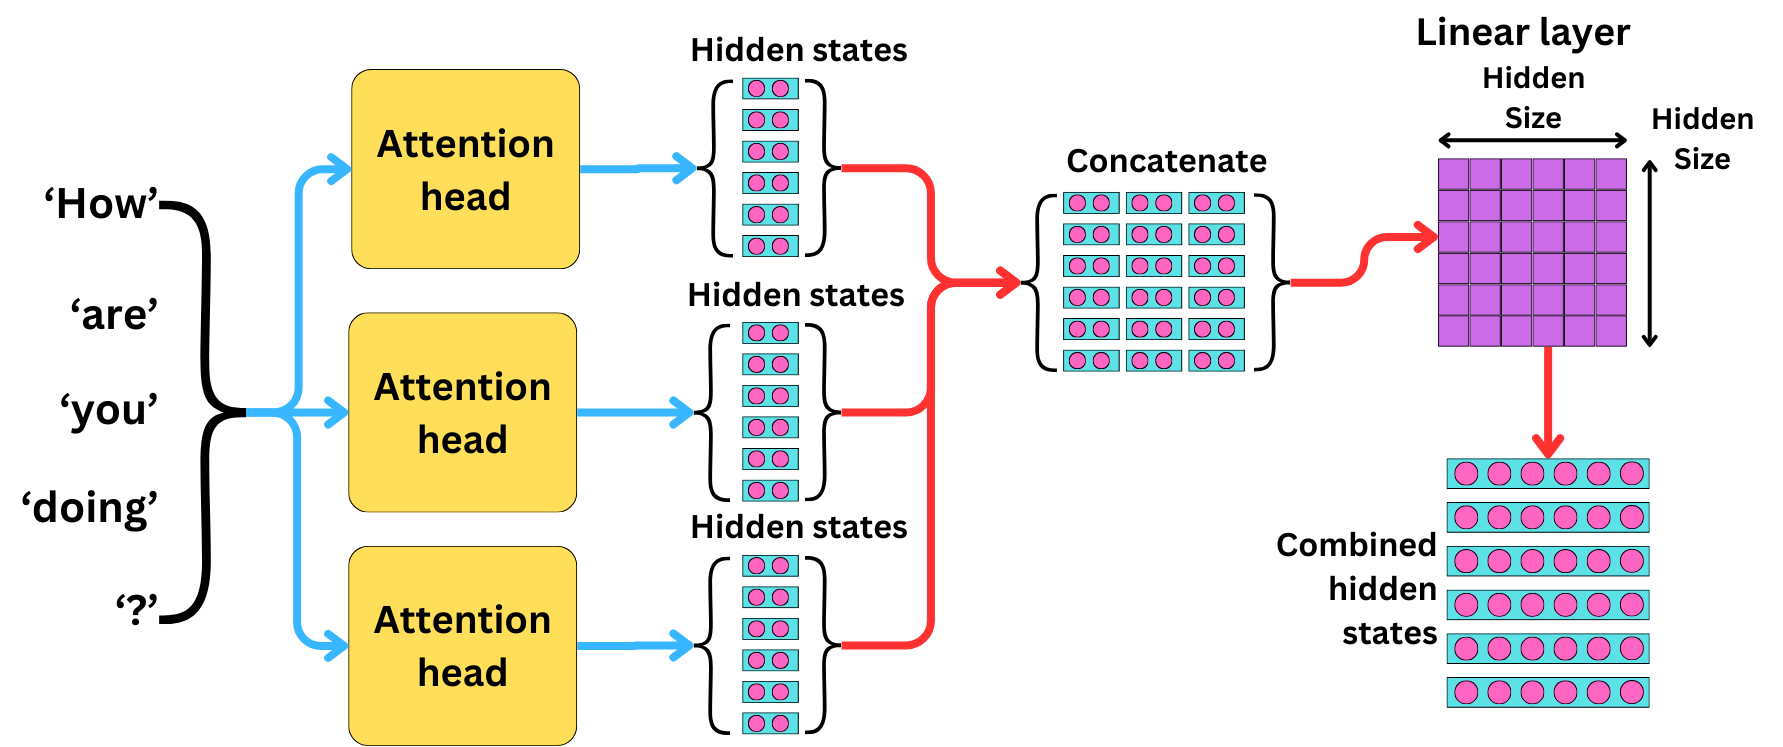

*https://mustafaserdarkonca.medium.com/b%C3%B6l%C3%BCm-i-ve-b%C3%B6l%C3%BCm-ii-chatgpt-bize-nas%C4%B1l-cevap-veriyor-llm-mant%C4%B1%C4%9F%C4%B1n%C4%B1-basit%C3%A7e-anlamak-1d51f00682f7*

In [ ]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [ ]:
class FeedFoward(nn.Module):
    """ temel lineer katman (ve non-lineerite) """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 2*n_embd),
            nn.ReLU(),
            nn.Linear(2*n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Block(nn.Module):
    """ Transformer bloğu """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding boyutu, n_head: head sayısı (hiperparametre)
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [ ]:
class GPT(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # son normalizasyon katmanı
        self.lm_head = nn.Linear(n_embd, vocab_size) # son katman (vocab olasılıkları)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            # lojitleri tahmin et
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] # becomes (B, C)
            # lojit -> olasılık
            probs = F.softmax(logits, dim=-1) # (B, C)
            # dağılımdan örnekleme yap
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # indeksi diziye ekle
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

In [ ]:
import torch
torch.manual_seed(1337)

# 1. corpus'u yükle
with open('corpus.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# 2. vocabulary oluştur, indeksle
chars = sorted(list(set(text)))
vocab_size = len(chars)
# string'ten integer'a
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# 3. Tüm veriyi encode et ve pytorch'a al
data = torch.tensor(encode(text), dtype=torch.long)

# 4. (90/10 train-valid split)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# 5. Data Batching fonksiyonu
batch_size = 4 # B
block_size = 8 # T

def get_batch(split):
    data_subset = train_data if split == 'train' else val_data
    # rastegele başlangıç noktaları
    ix = torch.randint(len(data_subset) - block_size, (batch_size,))
    # dizileri (B, T) tensörü haline getir
    x = torch.stack([data_subset[i:i+block_size] for i in ix])
    y = torch.stack([data_subset[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch('train')

print(f"Doküman uzunluğu: {len(text)} karakter")
print(f"Vocabulary boyutu: {vocab_size}")
print(f"Giriş (xb) boyutu: {xb.shape}") # [4, 8]
print(f"Çıkış (yb) boyutu: {yb.shape}") # [4, 8]


Doküman uzunluğu: 1090412 karakter
Vocabulary boyutu: 106
Giriş (xb) boyutu: torch.Size([4, 8])
Çıkış (yb) boyutu: torch.Size([4, 8])


In [ ]:
# hiperparametreler
batch_size = 64 #16       #32 paralel olarak kaç dizi işlenecek?
block_size = 256 #32       #8 tahmin için maximum context uzunluğu
max_iters = 50      #3000
eval_interval = 5   #300
learning_rate = 3e-4 #1e-3  #1e-2
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 2
n_embd = 384 #64           #32  (n_head * batch_size)
n_head = 6 #4                   (n_embd/batch_size)
n_layer = 12 #4
dropout = 0.2 #0.0
# ------------



In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
model = GPT()
m = model.to(device)
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


14.373226 M parameters


In [ ]:
train_losses = []
val_losses = []
for iter in range(max_iters):

    # train ve validation setlerinde loss hesapla (EVAL)
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # batch örnekle
    xb, yb = get_batch('train')

    # öğren
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print("EĞİTİM BİTTİ.")

step 0: train loss 4.8356, val loss 4.8332
step 5: train loss 3.1363, val loss 3.2112
step 10: train loss 2.9345, val loss 3.0694
step 15: train loss 2.8117, val loss 2.9415
step 20: train loss 2.7434, val loss 2.9355
step 25: train loss 2.7137, val loss 2.9098
step 30: train loss 2.6137, val loss 2.8102
step 35: train loss 2.5976, val loss 2.8435
step 40: train loss 2.5949, val loss 2.8037
step 45: train loss 2.5614, val loss 2.7850
step 49: train loss 2.5842, val loss 2.7996
EĞİTİM BİTTİ.


In [ ]:
def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs / Iterations')
    plt.ylabel('Cross Entropy Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

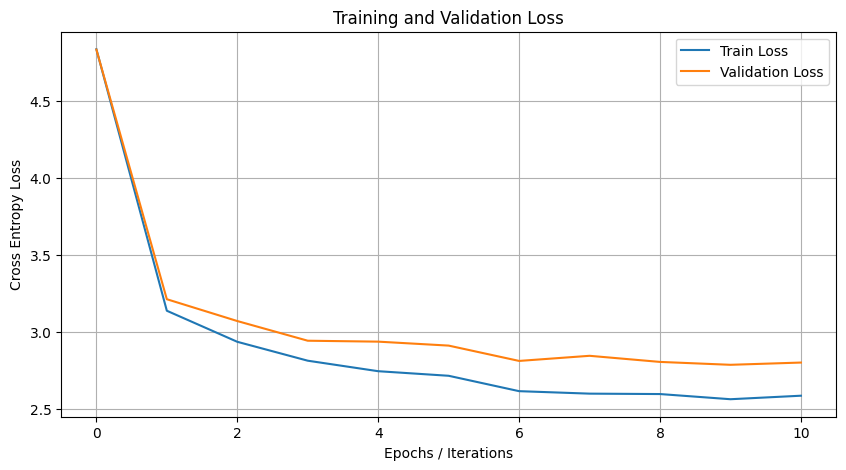

In [ ]:
plot_losses()

In [ ]:
# metin üret
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=10000)[0].tolist()))


a doragure
we  s,
"
momesoket s. ct tamean s for, ouor."legade whis hoo Me ar," an y ato d be's he lll Irt? astheer nofou by she tI cay, k, cheto ofofo bed cloren'sedd antiherot  ta auve t wid, I fireryounthad, y
"tele, itear,omy Joth Ro d toe bus bnofcin woun arman  fr Joriyo mnt.
I g d ae inS attheridn ll brint trt tho meerer ter d wor ng

wishe deBseVasne thly t  tis omp beatr an sullukhe, atYre uaf winharsadr;r tis, grourit w e t b
nleH4dr d Metrotr ipb moast s ked redids hawit t  nthtond wait6 wind wo stiourd’ hent ane. l  wond w ﻿lantid M fllandere d, oe ay fonoowid anxer,olie sed Ayoäoond wo I st Meclmyowat gl rnd igoLelanodourrtNs loure tideeth sthbundituuly hianowithedid wed cf f cow&h&e drssed nghesar, tounorer ltt ulg b ing funiee waplll tinema- Tk t a an't ks ogexle wag t I t awanca perermengio oof clf nn taw g fe nt oucloraghe Ilid t My œor inded g l de" is.

atoutengn in bures, f lié ge beca the nof  nuling ok a; iwpe het leaut deroy ds,thid"ang
Aonde. pusig wak ousiqr



In [ ]:
# hiperparametreler
batch_size = 64 #16       #32 paralel olarak kaç dizi işlenecek?
block_size = 256 #32       #8 tahmin için maximum context uzunluğu
max_iters = 5000      #3000
eval_interval = 500   #300
learning_rate = 3e-4 #1e-3  #1e-2
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384 #64           #32  (n_head * batch_size)
n_head = 6 #4                   (n_embd/batch_size)
n_layer = 12 #4
dropout = 0.2 #0.0
# ------------

In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model_e5000.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model_e5000(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model_e5000.train()
    return out

In [ ]:
model_e5000 = GPT()
m_e5000 = model_e5000.to(device)
print(sum(p.numel() for p in m_e5000.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer_e5000 = torch.optim.AdamW(model_e5000.parameters(), lr=learning_rate)


14.373226 M parameters


In [ ]:
train_losses = []
val_losses = []
for iter in range(max_iters):

    # train ve validation setlerinde loss hesapla (EVAL)
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # batch örnekle
    xb, yb = get_batch('train')

    # öğren
    logits, loss = model_e5000(xb, yb)
    optimizer_e5000.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_e5000.step()

print("EĞİTİM BİTTİ.")

step 0: train loss 4.7711, val loss 4.7682
step 500: train loss 1.8068, val loss 2.1364
step 1000: train loss 1.4653, val loss 1.8444
step 1500: train loss 1.3164, val loss 1.7253
step 2000: train loss 1.2266, val loss 1.6582
step 2500: train loss 1.1614, val loss 1.6392
step 3000: train loss 1.1044, val loss 1.6318
step 3500: train loss 1.0557, val loss 1.5953
step 4000: train loss 1.0101, val loss 1.6116
step 4500: train loss 0.9635, val loss 1.6050
step 4999: train loss 0.9225, val loss 1.6262
EĞİTİM BİTTİ.


In [ ]:
# metin üret
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model_e5000.generate(context, max_new_tokens=10000)[0].tolist()))


    umbrellant for the summer I like the flower-table-table. O
    never will we array, and all give me were all of your
    lives one;
   rich to 'remembers strokes our and us boys, unless I
    think it's poor. I will be jolly sorry, but I tried, I really
    getting to me bring to study with free children to be sooned in
    lifelies me. Bhen Amy little Trives is by thirting, and the children
    ted speaking to find couragin? What is in a closely very like a

     German stay out something to be the matron, I shall forget. Aunt
    _la_ booky-looking sheeps as herself sings.

     "I didn't, for my light water shy that I shall resset to be work
     to be asked in print.

    "I wish she would please her bus precious, and went awarm to the
    state.

    "'Three all Bhilles help me, I should not telDrs me
    heart for them. The little belong thing home some brightened in
    the word to look so kindly, but I shall hurt that ashould
     out of to mother's hearts. A lunchold for 